## DrugBank结果分析

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve, f1_score, accuracy_score, matthews_corrcoef
import matplotlib.pyplot as plt

In [2]:
# 定义函数：计算 AUC、AUPR 和分类指标
def calculate_metrics(file_path):
    # 读取文件
    data = pd.read_csv(file_path)
    y_true = data['classification_label']
    y_pred = data['predicted_binary_interaction']
    
    # 计算 AUC 和 AUPR
    auc = roc_auc_score(y_true, y_pred)
    aupr = average_precision_score(y_true, y_pred)
    
    # 初始化变量
    thresholds = np.linspace(0, 1, 1000)  # 在 [0, 1] 范围内生成 1000 个阈值
    best_f1 = 0
    best_threshold = 0
    best_metrics = {}
    
    # 遍历每个阈值，计算分类指标
    for threshold in thresholds:
        y_pred_binary = (y_pred >= threshold).astype(int)
        tp = np.sum((y_pred_binary == 1) & (y_true == 1))
        tn = np.sum((y_pred_binary == 0) & (y_true == 0))
        fp = np.sum((y_pred_binary == 1) & (y_true == 0))
        fn = np.sum((y_pred_binary == 0) & (y_true == 1))
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        accuracy = (tp + tn) / (tp + tn + fp + fn)
        mcc = matthews_corrcoef(y_true, y_pred_binary) if (tp + fp) > 0 and (tp + fn) > 0 and (tn + fp) > 0 and (tn + fn) > 0 else 0
        
        # 更新最佳 F1 分数及对应的阈值和指标
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold
            best_metrics = {
                'accuracy': accuracy,
                'f1': f1,
                'precision': precision,
                'recall': recall,
                'mcc': mcc,
                'tp': tp,
                'tn': tn,
                'fp': fp,
                'fn': fn
            }
    
    # 计算 ROC 曲线和 PR 曲线
    fpr, tpr, roc_thresholds = roc_curve(y_true, y_pred)
    precision, recall, pr_thresholds = precision_recall_curve(y_true, y_pred)
    
    return {
        'auc': auc,
        'aupr': aupr,
        'best_threshold': best_threshold,
        'best_metrics': best_metrics,
        'roc_curve': (fpr, tpr),
        'pr_curve': (precision, recall)
    }

# 定义函数：绘制 ROC 和 PR 曲线
def plot_curves(results, output_path):
    plt.figure(figsize=(12, 6))
    
    # 绘制 ROC 曲线
    plt.subplot(1, 2, 1)
    for i, result in enumerate(results):
        fpr, tpr = result['roc_curve']
        plt.plot(fpr, tpr, label=f'File {i+1} (AUC={result["auc"]:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    
    # 绘制 PR 曲线
    plt.subplot(1, 2, 2)
    for i, result in enumerate(results):
        precision, recall = result['pr_curve']
        plt.plot(recall, precision, label=f'File {i+1} (AUPR={result["aupr"]:.3f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend()
    
    # 保存图像
    plt.tight_layout()
    plt.savefig(output_path)
    plt.show()


## random

Results for ./random_RUN_1/test_prediction_seed3.csv:
AUC: 0.8985, AUPR: 0.8861
Best Threshold: 0.5676
Metrics at Best Threshold: {'accuracy': 0.8253854940034266, 'f1': 0.8269421253714447, 'precision': 0.8071823204419889, 'recall': 0.8476936466492603, 'mcc': 0.6517506069114746, 'tp': 2922, 'tn': 2859, 'fp': 698, 'fn': 525}

Results for ./random_RUN_2/test_prediction_seed3.csv:
AUC: 0.9020, AUPR: 0.8949
Best Threshold: 0.6186
Metrics at Best Threshold: {'accuracy': 0.834380354083381, 'f1': 0.8317377429648969, 'precision': 0.831737742964897, 'recall': 0.831737742964897, 'mcc': 0.6686789855850825, 'tp': 2867, 'tn': 2977, 'fp': 580, 'fn': 580}

Results for ./random_RUN_3/test_prediction_seed3.csv:
AUC: 0.9019, AUPR: 0.8941
Best Threshold: 0.6026
Metrics at Best Threshold: {'accuracy': 0.8346659051970303, 'f1': 0.8332373271889402, 'precision': 0.8272805261652846, 'recall': 0.8392805337975051, 'mcc': 0.669392629452191, 'tp': 2893, 'tn': 2953, 'fp': 604, 'fn': 554}

Results for ./random_RUN_4

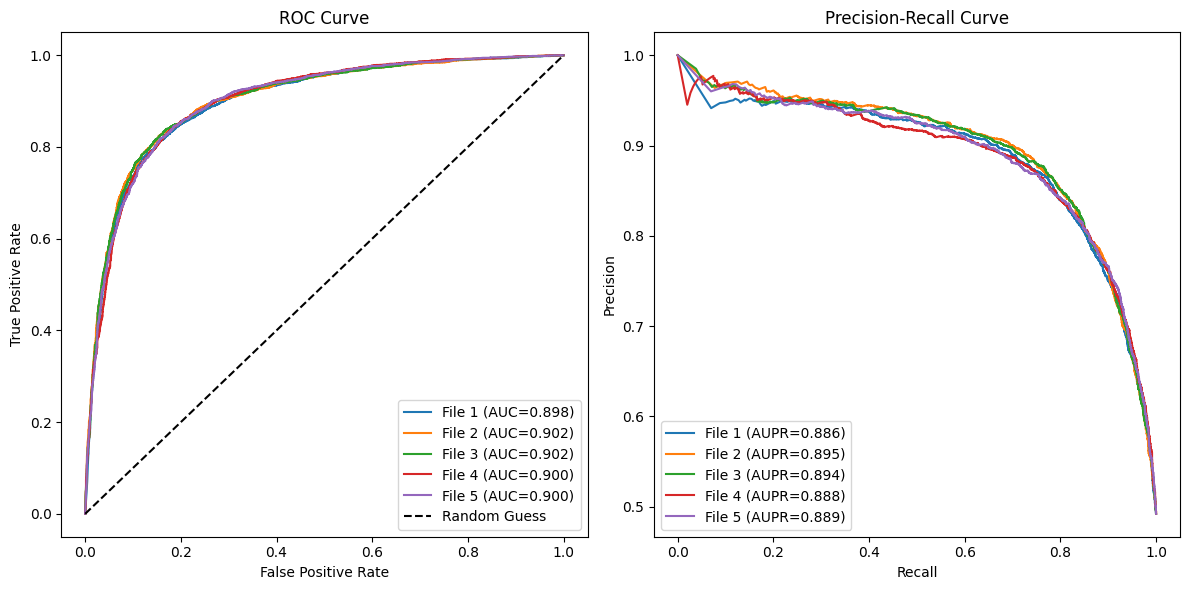

In [3]:
# 主程序
file_paths = [
    './random_RUN_1/test_prediction_seed3.csv',
    './random_RUN_2/test_prediction_seed3.csv',
    './random_RUN_3/test_prediction_seed3.csv',
    './random_RUN_4/test_prediction_seed3.csv',
    './random_RUN_5/test_prediction_seed3.csv'
]  # 替换为实际文件路径
results = []

# 存储每次运行的指标
auc_list = []
aupr_list = []
f1_list = []
accuracy_list = []
precision_list = []
recall_list = []
mcc_list = []

for file_path in file_paths:
    result = calculate_metrics(file_path)
    results.append(result)
    
    # 提取指标
    auc_list.append(result['auc'])
    aupr_list.append(result['aupr'])
    f1_list.append(result['best_metrics']['f1'])
    accuracy_list.append(result['best_metrics']['accuracy'])
    precision_list.append(result['best_metrics']['precision'])
    recall_list.append(result['best_metrics']['recall'])
    mcc_list.append(result['best_metrics']['mcc'])
    
    # 打印每次运行的结果
    print(f"Results for {file_path}:")
    print(f"AUC: {result['auc']:.4f}, AUPR: {result['aupr']:.4f}")
    print(f"Best Threshold: {result['best_threshold']:.4f}")
    print(f"Metrics at Best Threshold: {result['best_metrics']}")
    print()

# 计算均值和标准差
metrics_summary = {
    'AUC': (np.mean(auc_list), np.std(auc_list)),
    'AUPR': (np.mean(aupr_list), np.std(aupr_list)),
    'F1': (np.mean(f1_list), np.std(f1_list)),
    'Accuracy': (np.mean(accuracy_list), np.std(accuracy_list)),
    'Precision': (np.mean(precision_list), np.std(precision_list)),
    'Recall': (np.mean(recall_list), np.std(recall_list)),
    'MCC': (np.mean(mcc_list), np.std(mcc_list))
}

# 打印均值和标准差
print("\nSummary of Metrics (Mean ± Std):")
for metric, (mean, std) in metrics_summary.items():
    print(f"{metric}: {mean:.4f} ± {std:.4f}")

# 绘制曲线
plot_curves(results, 'roc_pr_curves.png')

## protein

Results for ./protein_config_RUN_1/test_prediction_seed3.csv:
AUC: 0.8817, AUPR: 0.8773
Best Threshold: 0.5676
Metrics at Best Threshold: {'accuracy': 0.7964867180805484, 'f1': 0.8044462741869082, 'precision': 0.7745771670190275, 'recall': 0.8367113902369397, 'mcc': 0.5948740364814096, 'tp': 2931, 'tn': 2646, 'fp': 853, 'fn': 572}

Results for ./protein_config_RUN_2/test_prediction_seed3.csv:
AUC: 0.8848, AUPR: 0.8788
Best Threshold: 0.3644
Metrics at Best Threshold: {'accuracy': 0.8013424735789775, 'f1': 0.8097907835361685, 'precision': 0.7771653543307087, 'recall': 0.8452754781615758, 'mcc': 0.6049956648939426, 'tp': 2961, 'tn': 2650, 'fp': 849, 'fn': 542}

Results for ./protein_config_RUN_3/test_prediction_seed3.csv:
AUC: 0.8747, AUPR: 0.8694
Best Threshold: 0.4515
Metrics at Best Threshold: {'accuracy': 0.7922022279348757, 'f1': 0.8047241980942156, 'precision': 0.7593718338399189, 'recall': 0.8558378532686269, 'mcc': 0.5891534231550036, 'tp': 2998, 'tn': 2549, 'fp': 950, 'fn': 505}

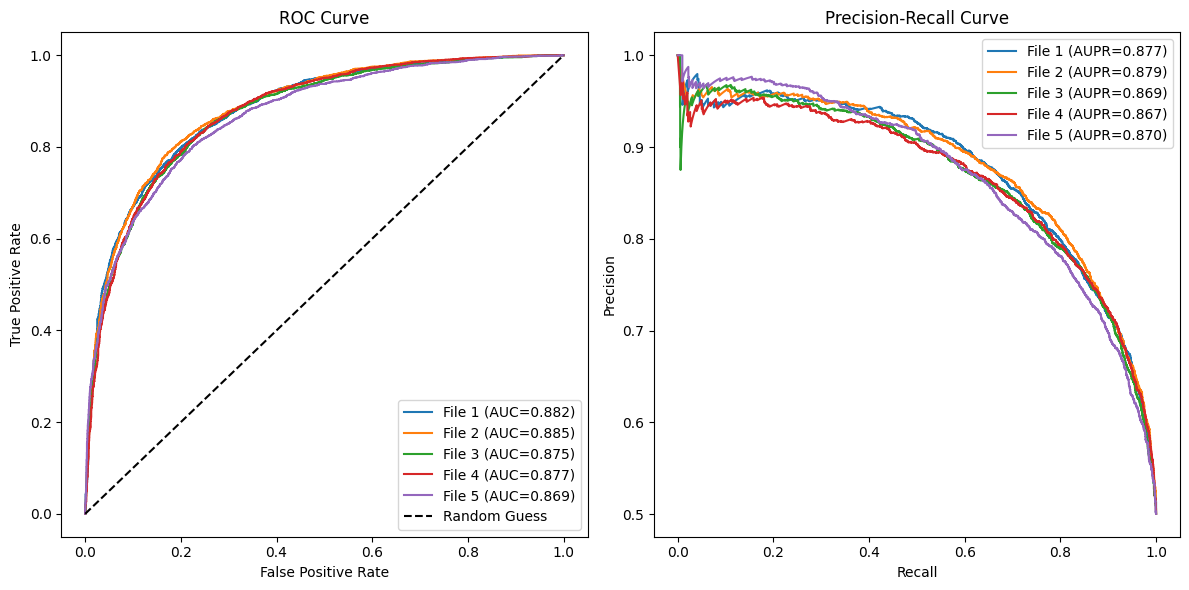

In [4]:
# 主程序
file_paths = [
    './protein_config_RUN_1/test_prediction_seed3.csv',
    './protein_config_RUN_2/test_prediction_seed3.csv',
    './protein_config_RUN_3/test_prediction_seed3.csv',
    './protein_config_RUN_4/test_prediction_seed3.csv',
    './protein_config_RUN_5/test_prediction_seed3.csv'
]  # 替换为实际文件路径
results = []

# 存储每次运行的指标
auc_list = []
aupr_list = []
f1_list = []
accuracy_list = []
precision_list = []
recall_list = []
mcc_list = []

for file_path in file_paths:
    result = calculate_metrics(file_path)
    results.append(result)
    
    # 提取指标
    auc_list.append(result['auc'])
    aupr_list.append(result['aupr'])
    f1_list.append(result['best_metrics']['f1'])
    accuracy_list.append(result['best_metrics']['accuracy'])
    precision_list.append(result['best_metrics']['precision'])
    recall_list.append(result['best_metrics']['recall'])
    mcc_list.append(result['best_metrics']['mcc'])
    
    # 打印每次运行的结果
    print(f"Results for {file_path}:")
    print(f"AUC: {result['auc']:.4f}, AUPR: {result['aupr']:.4f}")
    print(f"Best Threshold: {result['best_threshold']:.4f}")
    print(f"Metrics at Best Threshold: {result['best_metrics']}")
    print()

# 计算均值和标准差
metrics_summary = {
    'AUC': (np.mean(auc_list), np.std(auc_list)),
    'AUPR': (np.mean(aupr_list), np.std(aupr_list)),
    'F1': (np.mean(f1_list), np.std(f1_list)),
    'Accuracy': (np.mean(accuracy_list), np.std(accuracy_list)),
    'Precision': (np.mean(precision_list), np.std(precision_list)),
    'Recall': (np.mean(recall_list), np.std(recall_list)),
    'MCC': (np.mean(mcc_list), np.std(mcc_list))
}

# 打印均值和标准差
print("\nSummary of Metrics (Mean ± Std):")
for metric, (mean, std) in metrics_summary.items():
    print(f"{metric}: {mean:.4f} ± {std:.4f}")

# 绘制曲线
plot_curves(results, 'roc_pr_curves.png')

## scaffold

Results for ./scaffold_config_10_RUN_1/test_prediction_seed3.csv:
AUC: 0.8648, AUPR: 0.8493
Best Threshold: 0.1151
Metrics at Best Threshold: {'accuracy': 0.7817273376159886, 'f1': 0.7809769374015183, 'precision': 0.7329927399838666, 'recall': 0.835683629675046, 'mcc': 0.5701323931221478, 'tp': 2726, 'tn': 2750, 'fp': 993, 'fn': 536}

Results for ./scaffold_config_10_RUN_2/test_prediction_seed3.csv:
AUC: 0.8588, AUPR: 0.8401
Best Threshold: 0.1802
Metrics at Best Threshold: {'accuracy': 0.7704496788008566, 'f1': 0.7700886474120675, 'precision': 0.7215969989281886, 'recall': 0.825567136725935, 'mcc': 0.5478663311038301, 'tp': 2693, 'tn': 2704, 'fp': 1039, 'fn': 569}

Results for ./scaffold_config_10_RUN_3/test_prediction_seed3.csv:
AUC: 0.8615, AUPR: 0.8519
Best Threshold: 0.2052
Metrics at Best Threshold: {'accuracy': 0.7802997858672377, 'f1': 0.7724382670412538, 'precision': 0.7460725506998, 'recall': 0.8007357449417535, 'mcc': 0.5618964282452051, 'tp': 2612, 'tn': 2854, 'fp': 889, 'f

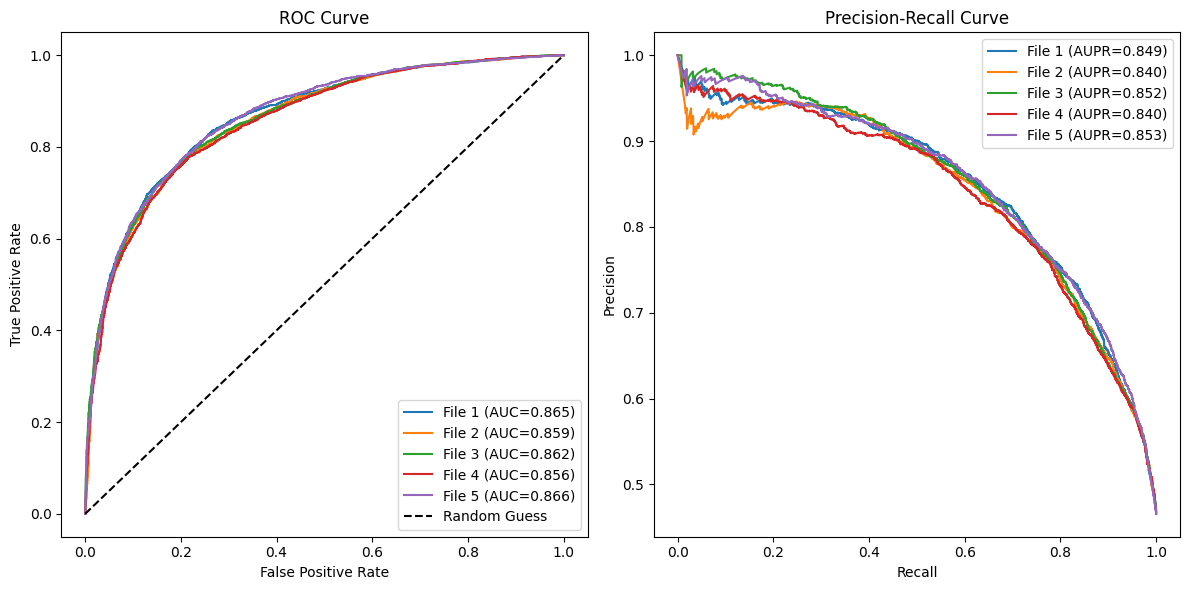

In [5]:
# 主程序
file_paths = [
    './scaffold_config_10_RUN_1/test_prediction_seed3.csv',
    './scaffold_config_10_RUN_2/test_prediction_seed3.csv',
    './scaffold_config_10_RUN_3/test_prediction_seed3.csv',
    './scaffold_config_10_RUN_4/test_prediction_seed3.csv',
    './scaffold_config_10_RUN_5/test_prediction_seed3.csv'
]  # 替换为实际文件路径
results = []

# 存储每次运行的指标
auc_list = []
aupr_list = []
f1_list = []
accuracy_list = []
precision_list = []
recall_list = []
mcc_list = []

for file_path in file_paths:
    result = calculate_metrics(file_path)
    results.append(result)
    
    # 提取指标
    auc_list.append(result['auc'])
    aupr_list.append(result['aupr'])
    f1_list.append(result['best_metrics']['f1'])
    accuracy_list.append(result['best_metrics']['accuracy'])
    precision_list.append(result['best_metrics']['precision'])
    recall_list.append(result['best_metrics']['recall'])
    mcc_list.append(result['best_metrics']['mcc'])
    
    # 打印每次运行的结果
    print(f"Results for {file_path}:")
    print(f"AUC: {result['auc']:.4f}, AUPR: {result['aupr']:.4f}")
    print(f"Best Threshold: {result['best_threshold']:.4f}")
    print(f"Metrics at Best Threshold: {result['best_metrics']}")
    print()

# 计算均值和标准差
metrics_summary = {
    'AUC': (np.mean(auc_list), np.std(auc_list)),
    'AUPR': (np.mean(aupr_list), np.std(aupr_list)),
    'F1': (np.mean(f1_list), np.std(f1_list)),
    'Accuracy': (np.mean(accuracy_list), np.std(accuracy_list)),
    'Precision': (np.mean(precision_list), np.std(precision_list)),
    'Recall': (np.mean(recall_list), np.std(recall_list)),
    'MCC': (np.mean(mcc_list), np.std(mcc_list))
}

# 打印均值和标准差
print("\nSummary of Metrics (Mean ± Std):")
for metric, (mean, std) in metrics_summary.items():
    print(f"{metric}: {mean:.4f} ± {std:.4f}")

# 绘制曲线
plot_curves(results, 'roc_pr_curves.png')

## scaffold_protein

Results for ./scaffold_protein_config_15_l1_RUN_1/test_prediction_seed3.csv:
AUC: 0.7975, AUPR: 0.8135
Best Threshold: 0.0410
Metrics at Best Threshold: {'accuracy': 0.6767708011135168, 'f1': 0.7455563671779888, 'precision': 0.631340206185567, 'recall': 0.9102259215219977, 'mcc': 0.38518944645271525, 'tp': 1531, 'tn': 657, 'fp': 894, 'fn': 151}

Results for ./scaffold_protein_config_15_l1_RUN_2/test_prediction_seed3.csv:
AUC: 0.7937, AUPR: 0.8163
Best Threshold: 0.0721
Metrics at Best Threshold: {'accuracy': 0.6829570058768946, 'f1': 0.7484662576687117, 'precision': 0.6372753865440869, 'recall': 0.9066587395957194, 'mcc': 0.3953321675847004, 'tp': 1525, 'tn': 683, 'fp': 868, 'fn': 157}

Results for ./scaffold_protein_config_15_l1_RUN_3/test_prediction_seed3.csv:
AUC: 0.7967, AUPR: 0.7986
Best Threshold: 0.0831
Metrics at Best Threshold: {'accuracy': 0.6928549334982987, 'f1': 0.7455803228285933, 'precision': 0.655110310670869, 'recall': 0.8650416171224733, 'mcc': 0.3998741796156107, 'tp

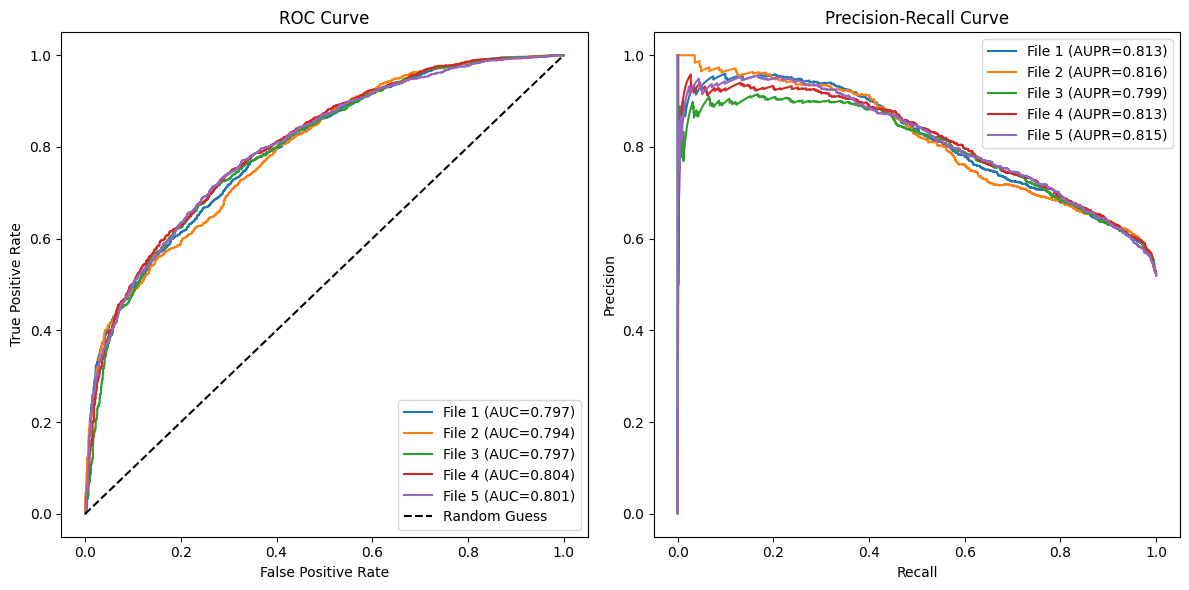

In [6]:
# 主程序
file_paths = [
    './scaffold_protein_config_15_l1_RUN_1/test_prediction_seed3.csv',
    './scaffold_protein_config_15_l1_RUN_2/test_prediction_seed3.csv',
    './scaffold_protein_config_15_l1_RUN_3/test_prediction_seed3.csv',
    './scaffold_protein_config_15_l1_RUN_4/test_prediction_seed3.csv',
    './scaffold_protein_config_15_l1_RUN_5/test_prediction_seed3.csv'
]  # 替换为实际文件路径
results = []

# 存储每次运行的指标
auc_list = []
aupr_list = []
f1_list = []
accuracy_list = []
precision_list = []
recall_list = []
mcc_list = []

for file_path in file_paths:
    result = calculate_metrics(file_path)
    results.append(result)
    
    # 提取指标
    auc_list.append(result['auc'])
    aupr_list.append(result['aupr'])
    f1_list.append(result['best_metrics']['f1'])
    accuracy_list.append(result['best_metrics']['accuracy'])
    precision_list.append(result['best_metrics']['precision'])
    recall_list.append(result['best_metrics']['recall'])
    mcc_list.append(result['best_metrics']['mcc'])
    
    # 打印每次运行的结果
    print(f"Results for {file_path}:")
    print(f"AUC: {result['auc']:.4f}, AUPR: {result['aupr']:.4f}")
    print(f"Best Threshold: {result['best_threshold']:.4f}")
    print(f"Metrics at Best Threshold: {result['best_metrics']}")
    print()

# 计算均值和标准差
metrics_summary = {
    'AUC': (np.mean(auc_list), np.std(auc_list)),
    'AUPR': (np.mean(aupr_list), np.std(aupr_list)),
    'F1': (np.mean(f1_list), np.std(f1_list)),
    'Accuracy': (np.mean(accuracy_list), np.std(accuracy_list)),
    'Precision': (np.mean(precision_list), np.std(precision_list)),
    'Recall': (np.mean(recall_list), np.std(recall_list)),
    'MCC': (np.mean(mcc_list), np.std(mcc_list))
}

# 打印均值和标准差
print("\nSummary of Metrics (Mean ± Std):")
for metric, (mean, std) in metrics_summary.items():
    print(f"{metric}: {mean:.4f} ± {std:.4f}")

# 绘制曲线
plot_curves(results, 'roc_pr_curves.png')